In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from pathlib import Path

# 设置绘图风格
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100


In [16]:
# 读取spike_detection的结果
detection_dir = Path('spike_detection/eval_result')
samples = [d.name for d in detection_dir.iterdir() if d.is_dir()]
samples = sorted(samples)

print(f"找到 {len(samples)} 个样本: {samples}")

# 收集每个样本的accuracy数据
detection_data = {}

for sample in samples:
    accuracy_file = detection_dir / sample / 'accuracy_dict.pkl'
    
    if accuracy_file.exists():
        with open(accuracy_file, 'rb') as f:
            accuracy_dict = pickle.load(f)
        
        # 将所有accuracy值收集到一个列表中
        all_accuracies = []
        for key, accuracies in accuracy_dict.items():
            all_accuracies.extend(accuracies)
        
        detection_data[sample] = all_accuracies
        print(f"样本 {sample}: {len(accuracy_dict)} 个cliques, 共 {len(all_accuracies)} 个accuracy值")

print(f"\n总共收集了 {len(detection_data)} 个样本的数据")


找到 4 个样本: ['810755799', '810755801', '810755803', '810755807']
样本 810755799: 68 个cliques, 共 340 个accuracy值
样本 810755801: 143 个cliques, 共 715 个accuracy值
样本 810755803: 111 个cliques, 共 555 个accuracy值
样本 810755807: 72 个cliques, 共 360 个accuracy值

总共收集了 4 个样本的数据


In [35]:
len(data_for_plot[1])


715

/tmp/ipykernel_2837499/3974627686.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')


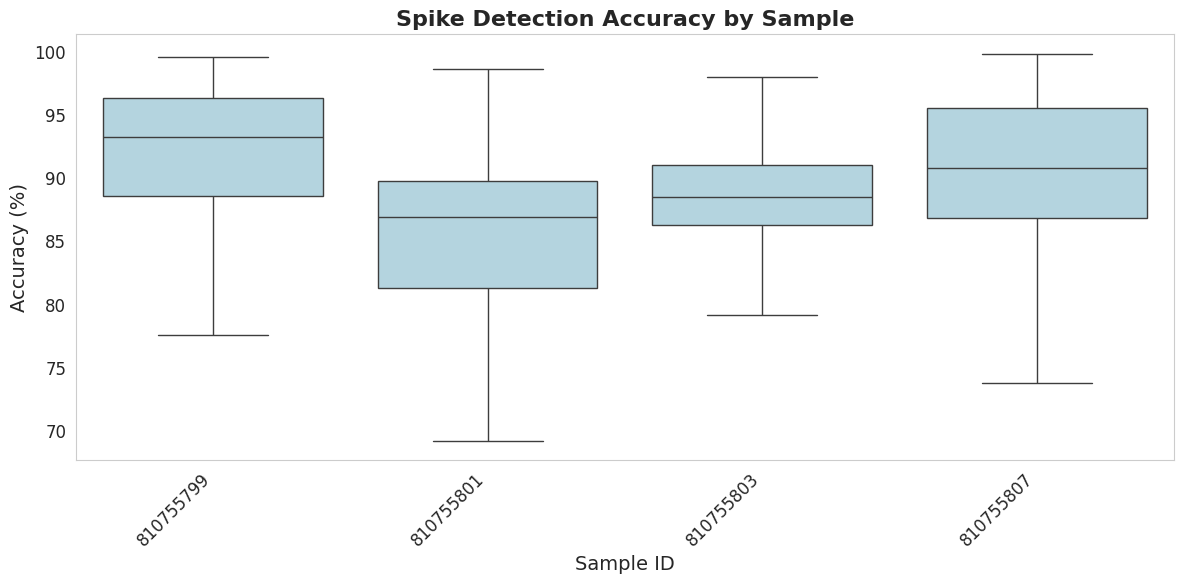

In [ ]:
# 绘制Spike Detection的boxplot
fig, ax = plt.subplots(figsize=(12, 6))

data_for_plot = [detection_data[sample] for sample in samples]
labels = samples

# 绘制boxplot
bp = sns.boxplot(data_for_plot, showfliers = False, color = 'lightblue')

ax.set_title('Spike Detection Accuracy by Sample', fontsize=16, fontweight='bold')
ax.set_xlabel('Sample ID', fontsize=14)
ax.set_ylabel('Accuracy (%)', fontsize=14)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.grid(False)

plt.tight_layout()
plt.savefig('spike_detection_accuracy_boxplot.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [39]:
# 读取spike_classification的结果
classification_dir = Path('spike_classification/eval_result')
samples_class = [d.name for d in classification_dir.iterdir() if d.is_dir()]
samples_class = sorted(samples_class)

print(f"找到 {len(samples_class)} 个样本: {samples_class}")

# 收集每个样本的所有clique的accuracy数据
classification_data = {}

for sample in samples_class:
    sample_dir = classification_dir / sample
    
    # 获取所有clique目录
    cliques = [d.name for d in sample_dir.iterdir() if d.is_dir()]
    
    all_accuracies = []
    
    for clique in cliques:
        clique_dir = sample_dir / clique
        
        # 读取该clique的所有accuracy文件
        for i in range(1, 6):  # accuracy_1.pkl 到 accuracy_5.pkl
            accuracy_file = clique_dir / f'accuracy_{i}.pkl'
            
            if accuracy_file.exists():
                with open(accuracy_file, 'rb') as f:
                    accuracies = pickle.load(f)
                
                # accuracies是一个列表，包含多个accuracy值
                if isinstance(accuracies, list):
                    all_accuracies.extend(accuracies)
                else:
                    all_accuracies.append(accuracies)
    
    classification_data[sample] = all_accuracies
    print(f"样本 {sample}: {len(cliques)} 个cliques, 共 {len(all_accuracies)} 个accuracy值")

print(f"\n总共收集了 {len(classification_data)} 个样本的数据")


找到 4 个样本: ['810755799', '810755801', '810755803', '810755807']
样本 810755799: 68 个cliques, 共 866 个accuracy值
样本 810755801: 68 个cliques, 共 874 个accuracy值
样本 810755803: 68 个cliques, 共 878 个accuracy值
样本 810755807: 72 个cliques, 共 815 个accuracy值

总共收集了 4 个样本的数据


/tmp/ipykernel_2837499/3011771628.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


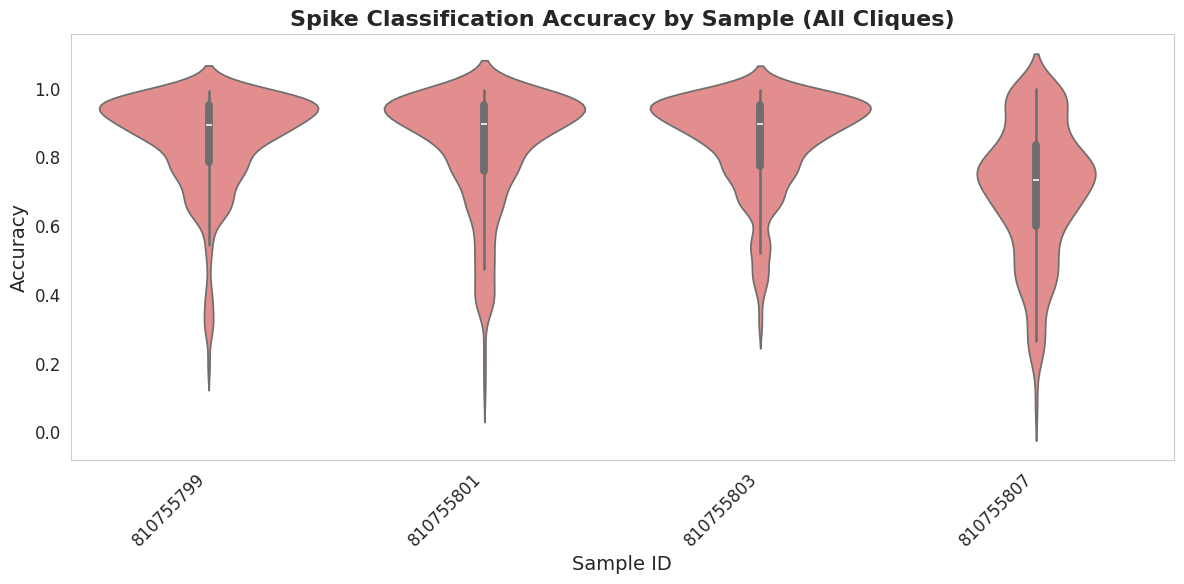


=== Spike Classification Statistics ===
810755799: Mean=0.8494, Std=0.1425, Median=0.8950, N=866
810755801: Mean=0.8296, Std=0.1684, Median=0.8963, N=874
810755803: Mean=0.8479, Std=0.1380, Median=0.8970, N=878
810755807: Mean=0.7040, Std=0.1963, Median=0.7342, N=815


In [ ]:
# 绘制Spike Classification的boxplot
fig, ax = plt.subplots(figsize=(12, 6))

# 准备数据用于boxplot
data_for_plot_class = [classification_data[sample] for sample in samples_class]
labels_class = samples_class

# 绘制boxplot
bp = ax.boxplot(data_for_plot_class, labels=labels_class, patch_artist=True,
                showmeans=True, meanline=True,
                boxprops=dict(facecolor='lightcoral', alpha=0.7),
                medianprops=dict(color='darkred', linewidth=2),
                meanprops=dict(color='darkgreen', linewidth=2, linestyle='--'))

# 设置标题和标签
ax.set_title('Spike Classification Accuracy by Sample (All Cliques)', fontsize=16, fontweight='bold')
ax.set_xlabel('Sample ID', fontsize=14)
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_xticklabels(labels_class, rotation=45, ha='right')
ax.grid(True, alpha=0.3)

# 添加水平线表示整体平均值
all_values_class = [val for vals in data_for_plot_class for val in vals]
overall_mean_class = np.mean(all_values_class)
ax.axhline(y=overall_mean_class, color='purple', linestyle=':', linewidth=2, 
           label=f'Overall Mean: {overall_mean_class:.4f}')

plt.tight_layout()
plt.savefig('spike_classification_accuracy_boxplot.pdf', dpi=300, bbox_inches='tight')
plt.show()

# 打印统计信息
print("\n=== Spike Classification Statistics ===")
for sample, accuracies in classification_data.items():
    print(f"{sample}: Mean={np.mean(accuracies):.4f}, Std={np.std(accuracies):.4f}, "
          f"Median={np.median(accuracies):.4f}, N={len(accuracies)}")
print(f"\nOverall: Mean={overall_mean_class:.4f}, Std={np.std(all_values_class):.4f}")


In [44]:
# 准备数据：将detection和classification数据合并成DataFrame
combined_data = []

# 添加detection数据
for sample in samples:
    if sample in detection_data:
        for accuracy in detection_data[sample]:
            combined_data.append({
                'Sample': sample,
                'Task': 'Detection',
                'Accuracy': accuracy
            })

# 添加classification数据
for sample in samples_class:
    if sample in classification_data:
        for accuracy in classification_data[sample]:
            combined_data.append({
                'Sample': sample,
                'Task': 'Classification',
                'Accuracy': accuracy * 100
            })

combined_df = pd.DataFrame(combined_data)
print(f"Combined data shape: {combined_df.shape}")
print(f"\nSamples in combined data: {combined_df['Sample'].unique()}")
print(f"Tasks: {combined_df['Task'].unique()}")


Combined data shape: (5403, 3)

Samples in combined data: ['810755799' '810755801' '810755803' '810755807']
Tasks: ['Detection' 'Classification']


/tmp/ipykernel_2837499/2843369012.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


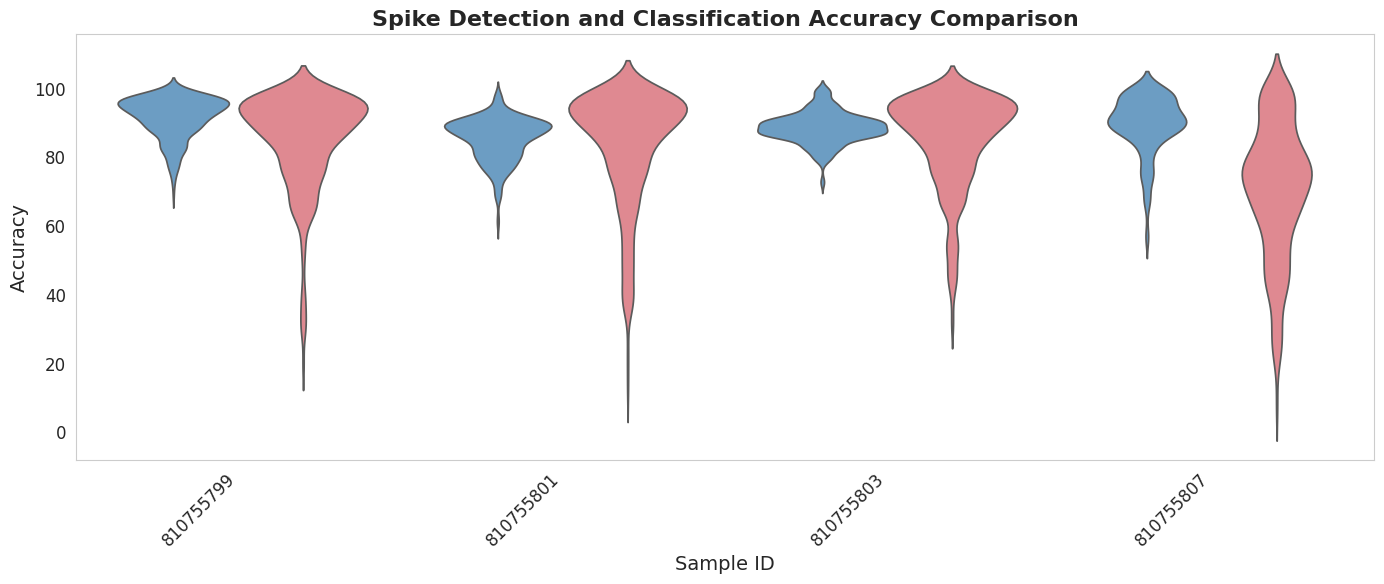

In [57]:
# 绘制Combined Violin Plot
fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(data=combined_df, x='Sample', y='Accuracy', hue='Task',
               split=False, palette={'Detection': '#5E9FD1', 'Classification': '#ED7B85'},
               ax=ax, inner = None)

ax.set_title('Spike Detection and Classification Accuracy Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Sample ID', fontsize=14)
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(False)

ax.get_legend().remove()


plt.tight_layout()
plt.savefig('combined_violin_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()
